# Subspace Track-before-Detect for Passive Multi-Target Tracking with Unknown Emitted Signals

This notebook runs a passive multi-target track-before-detect simulation with unknown emitted signals. It compares a Bingham-likelihood-based subspace track-before-detect method with a Gaussian baseline under the same trajectory, observation, and random seed.
The setup uses a sinc-correlated noise simulation and soft spatial boundary weighting.

c 2026 National Institute of Advanced Industrial Science and Technology（AIST）

## Imports and global parameters


In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np
from filterpy.monte_carlo import systematic_resample


In [ ]:
SOUND_SPEED = 343.0
ROOM_SIZE = 3.0

RUN_SNR_DB = 10
RUN_NPARTICLES = 2000 # Number of particles
RUN_SEED = 20260526 # Random seed

DT = 0.128 # Time step [s]
T_STEPS = 200 # Number of time frames
N_TARGETS = 2 # Number of targets

BIRTH_VEL_STD_SIM = 0.5
BIRTH_VEL_STD_FILTER = 0.5
ACTIVITY_LENGTHS = [100, 100]
ACTIVITY_PHASES = [1, 2]

N_MICS = 40 # Number of microphones
FREQS = np.linspace(101.6, 570.3, 61)

BINGHAM_KAPPA = 10
SOFT_BOUNDARY_TAU = 0.05
STEERING_EPS = 1e-9
OBS_EPS = 1e-12
WEIGHT_EPS = 1e-12

F = np.array(
    [
        [1, 0, DT, 0],
        [0, 1, 0, DT],
        [0, 0, 1, 0],
        [0, 0, 0, 1],
    ]
)
Q = 0.09 * np.array(
    [
        [DT**4 / 4, 0, DT**3 / 2, 0],
        [0, DT**4 / 4, 0, DT**3 / 2],
        [DT**3 / 2, 0, DT**2, 0],
        [0, DT**3 / 2, 0, DT**2],
    ]
)
TRANSITION_PROB = np.array([[0.9975, 0.0025], [0.1, 0.9]]) # Not used
BIRTH_BOUNDS = (0, ROOM_SIZE, 0, ROOM_SIZE)


## Microphone geometry

This section constructs the microphone positions. `make_square_perimeter_micpos` places microphones uniformly along the perimeter of the square room. 


In [ ]:
def make_square_perimeter_micpos(na, L):
    perimeter = 4 * L
    s = perimeter / na
    micpos = np.zeros((na, 2), dtype=float)
    for k in range(na):
        d = k * s
        # d = (k * s) % perimeter
        if d < L:
            micpos[k] = [d, 0.0]
        elif d < 2 * L:
            micpos[k] = [L, d - L]
        elif d < 3 * L:
            micpos[k] = [3 * L - d, L]
        else:
            micpos[k] = [0.0, 4 * L - d]
    return micpos


micpos = make_square_perimeter_micpos(N_MICS, ROOM_SIZE)


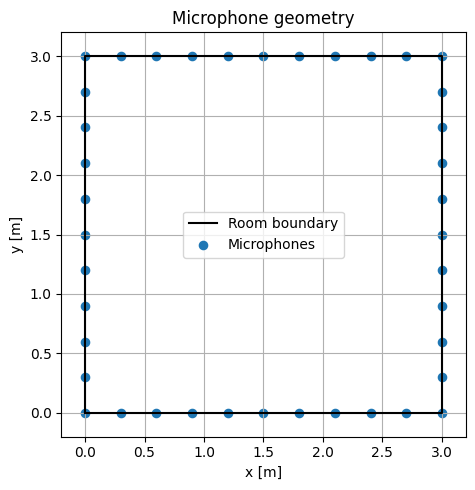

In [ ]:
plt.figure(figsize=(5, 5))
room_x = [0, ROOM_SIZE, ROOM_SIZE, 0, 0]
room_y = [0, 0, ROOM_SIZE, ROOM_SIZE, 0]
plt.plot(room_x, room_y, "k-", lw=1.5, label="Room boundary")
plt.scatter(micpos[:, 0], micpos[:, 1], s=35, label="Microphones")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Microphone geometry")
plt.gca().set_aspect("equal", adjustable="box")
plt.xlim(-0.2, ROOM_SIZE + 0.2)
plt.ylim(-0.2, ROOM_SIZE + 0.2)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## Target motion and birth models

This section defines the target motion and birth models used by both the simulator and the particle filter. `ps` propagates surviving target states using a linear dynamical model and process noise. `pb` samples newly born targets inside the room with random velocity.

In [ ]:
def ps(x, F, Q):
    """Propagate particle states with a linear dynamical model."""
    return x @ F.T + np.random.multivariate_normal(
        mean=np.zeros(x.shape[1]),
        cov=Q,
        size=x.shape[0],
    )


def pb(n_birth, birth_bounds, birth_vel_std):
    """Sample newly born target states inside the room."""
    xmin, xmax, ymin, ymax = birth_bounds
    xy = np.column_stack(
        [
            np.random.uniform(xmin, xmax, n_birth),
            np.random.uniform(ymin, ymax, n_birth),
        ]
    )
    vxy = np.random.normal(0.0, birth_vel_std, size=(n_birth, 2))
    return np.hstack([xy, vxy])


def steering_vectors(x, active, micpos=micpos, freqs=FREQS, c=SOUND_SPEED):
    """Compute steering vectors for active target slots."""
    active = active.astype(bool)
    diff = micpos[None, None, :, :] - x[:, :, None, :2]
    r = np.linalg.norm(diff, axis=3) + STEERING_EPS
    phase = -1j * 2.0 * np.pi * freqs[:, None, None, None] * r[None, ...] / c
    sv = np.exp(phase) / r[None, ...]
    sv = sv.transpose(0, 1, 3, 2)
    return sv * active[None, :, None, :]


def soft_boundary_mask(x, active, birth_bounds=BIRTH_BOUNDS, tau=SOFT_BOUNDARY_TAU):
    """Return a soft in-room weight for active target slots."""
    xmin, xmax, ymin, ymax = birth_bounds
    active = active.astype(bool)
    ox = np.maximum(0.0, xmin - x[:, :, 0]) + np.maximum(0.0, x[:, :, 0] - xmax)
    oy = np.maximum(0.0, ymin - x[:, :, 1]) + np.maximum(0.0, x[:, :, 1] - ymax)
    soft_in = np.exp(-((ox**2 + oy**2) / (tau**2)))
    per_slot = (~active).astype(float) + active.astype(float) * soft_in
    return np.prod(per_slot, axis=1)


## Likelihood functions

This section defines the two observation likelihoods compared in the experiment. `lik_bingham` scores normalized multichannel observations using the subspace Bingham distribution. `lik_gauss` is the conventional Gaussian baseline based on squared residual energy.


In [ ]:
def lik_bingham(z, x, a, micpos, freqs, c, noise_var=None, birth_bounds=None):
    """Evaluate the Bingham likelihood for each particle."""
    # noise_var is unused for the Bingham subspace likelihood.
    # The uncertainty/concentration is controlled by kappa instead.
    if z.ndim == 1:
        z = z.reshape(len(freqs), micpos.shape[0])
    z = z.astype(np.complex128, copy=False)
    z_norm = np.linalg.norm(z, axis=1, keepdims=True) + STEERING_EPS
    z = z / z_norm
    sv_all = steering_vectors(x, a, micpos, freqs, c)

    # Project the normalized observation onto each particle's steering subspace.
    z_exp = z[:, None, :, None]
    Ah = sv_all.conj().transpose(0, 1, 3, 2)
    Ahz = Ah @ z_exp
    G = Ah @ sv_all
    G = G + STEERING_EPS * np.eye(G.shape[-1])[None, None, :, :]
    y = np.linalg.solve(G, Ahz)
    proj = np.real((Ahz.conj() * y).sum(axis=2).squeeze(-1))
    ll = BINGHAM_KAPPA * proj.sum(axis=0)
    ll -= np.max(ll)
    mask = soft_boundary_mask(x, a, birth_bounds)
    return np.exp(ll) * mask


In [ ]:
def lik_gauss(z, x, a, micpos, freqs, c, noise_var, birth_bounds):
    """Evaluate the Gaussian squared-residual likelihood for each particle."""
    if z.ndim == 1:
        z = z.reshape(len(freqs), micpos.shape[0])
    z = z.astype(np.complex128, copy=False)
    sv_all = steering_vectors(x, a, micpos, freqs, c)
    s = np.sum(sv_all, axis=3)
    z_exp = z[:, None, :]
    ll = -np.sum(np.linalg.norm(s - z_exp, axis=2) ** 2, axis=0) / noise_var
    ll -= np.max(ll)
    mask = soft_boundary_mask(x, a, birth_bounds)
    return np.exp(ll) * mask


## Particle filter

This section implements the track-before-detect particle filter used by both methods.
`TrackBeforeDetect` stores particle states, activity indicators, weights, and the particle history used for visualization.
The only intended method difference in the experiment is the likelihood function passed to the filter.
`noise_var` is passed explicitly because it is determined by the simulated SNR condition.


In [ ]:
class TrackBeforeDetect:
    """Particle-filter tracker shared by the Gaussian and Bingham likelihoods."""

    def __init__(
        self,
        lik,
        noise_var,
        nparticles=RUN_NPARTICLES,
        nmax=N_TARGETS,
        P=TRANSITION_PROB,
        F=F,
        Q=Q,
        micpos=micpos,
        freqs=FREQS,
        birth_bounds=BIRTH_BOUNDS,
        birth_vel_std=BIRTH_VEL_STD_FILTER,
        c=SOUND_SPEED,
        T=T_STEPS,
    ):
        self.nparticles = nparticles
        self.nmax = nmax
        self.P = P
        self.F = F
        self.Q = Q
        self.lik = lik
        self.x = np.zeros((nparticles, nmax, F.shape[0]), dtype=np.float64)
        self.history = []
        self.a = np.zeros((nparticles, nmax), dtype=int)
        self.w = np.full(nparticles, 1.0 / nparticles)
        self.micpos = micpos
        self.freqs = freqs
        self.birth_bounds = birth_bounds
        self.birth_vel_std = birth_vel_std
        self.c = c
        self.noise_var = noise_var
        self.T = T

    def _propagate(self, x, a0, a1):
        e_x = np.empty_like(x)
        mask_s = (a0 == 1) & (a1 == 1)
        mask_b = (a0 == 0) & (a1 == 1)
        mask_0 = a1 == 0
        if mask_0.any():
            e_x[mask_0] = x[mask_0]
        if mask_s.any():
            e_x[mask_s] = ps(x[mask_s], self.F, self.Q)
        if mask_b.any():
            e_x[mask_b] = pb(mask_b.sum(), self.birth_bounds, self.birth_vel_std)
        return e_x

    def step(self, z_t, a_prev, a_curr):
        a_prev = np.broadcast_to(a_prev, (self.nparticles, self.nmax)).astype(int)
        a_curr = np.broadcast_to(a_curr, (self.nparticles, self.nmax)).astype(int)
        e_x = self._propagate(self.x, a_prev, a_curr)
        w_tilde = (
            self.lik(
                z_t,
                e_x,
                a_curr,
                self.micpos,
                self.freqs,
                self.c,
                self.noise_var,
                self.birth_bounds,
            )
            * self.w
        )
        if np.all(w_tilde == 0):
            w_tilde[:] = 1.0 / self.nparticles
        else:
            w_tilde /= np.sum(w_tilde)

        # Resample from the proposal weights, then correct the particle weights.
        parent = systematic_resample(w_tilde)
        a0 = a_prev[parent]
        a1 = a_curr
        nx = self._propagate(self.x[parent], a0, a1)
        num = self.lik(
            z_t,
            nx,
            a1,
            self.micpos,
            self.freqs,
            self.c,
            self.noise_var,
            self.birth_bounds,
        )
        dnm = self.lik(
            z_t,
            e_x[parent],
            a1[parent],
            self.micpos,
            self.freqs,
            self.c,
            self.noise_var,
            self.birth_bounds,
        )
        self.w = num / (dnm + WEIGHT_EPS)
        if np.all(self.w == 0):
            self.w[:] = 1.0 / self.nparticles
        else:
            self.w /= np.sum(self.w)
        self.x = nx
        self.history.append(nx.copy())
        self.a = a1

    def mmse(self):
        xs = np.zeros((self.nmax, self.x.shape[2]))
        ah = np.zeros(self.nmax, int)
        for j in range(self.nmax):
            wa = self.w * self.a[:, j]
            dnm = np.sum(wa)
            if dnm > 0:
                xs[j] = np.sum(wa[:, None] * self.x[:, j], axis=0) / dnm
            else:
                xs[j] = np.zeros(self.x.shape[2])
            ah[j] = int(np.sum(wa) >= 0.5)
        return xs, ah


## Data generation

This section creates the ground-truth activity pattern, target trajectories, and complex-valued sensor observations.
`generate_activity` specifies when one or two targets are active.
`generate_trajectories` samples in-room target paths consistent with that activity pattern.
`simulate_obs` generates multichannel frequency-domain observations with sinc-correlated additive noise at the specified SNR.


In [ ]:
def generate_activity(
    lengths=ACTIVITY_LENGTHS,
    phases=ACTIVITY_PHASES,
    T=T_STEPS,
    nmax=N_TARGETS,
):
    """Create the given ground-truth activity pattern for the simulation."""
    true_active = np.zeros((T, nmax), int)
    t0 = 0
    for seg_len, phase_id in zip(lengths, phases):
        true_active[t0:t0 + seg_len, :phase_id] = 1
        t0 += seg_len
    return true_active


In [ ]:
def generate_trajectories(
    true_active,
    T=T_STEPS,
    nmax=N_TARGETS,
    F=F,
    Q=Q,
    L=ROOM_SIZE,
    birth_vel_std=BIRTH_VEL_STD_SIM,
    max_tries=10000,
):
    """Sample in-room target trajectories for the given activity pattern."""
    xmin, xmax, ymin, ymax = 0.0, L, 0.0, L
    nx = F.shape[0]
    true_states = np.zeros((T, nmax, nx))
    for j in range(nmax):
        for _ in range(max_tries):
            path = np.zeros((T, nx))
            path[0] = pb(1, (xmin, xmax, ymin, ymax), birth_vel_std)[0]
            for t in range(1, T):
                path[t] = ps(path[t - 1][None, :], F, Q)[0]
            in_x = (xmin <= path[:, 0]) & (path[:, 0] <= xmax)
            in_y = (ymin <= path[:, 1]) & (path[:, 1] <= ymax)
            mask = true_active[:, j] == 1
            if np.all((in_x & in_y)[mask]):
                true_states[:, j] = path
                break
        else:
            raise RuntimeError(
                f"Failed to generate in-bounds trajectory for target {j}"
            )
    return true_states


In [ ]:
def simulate_obs(
    true_states,
    true_active,
    target_snr_db,
    micpos=micpos,
    freqs=FREQS,
    c=SOUND_SPEED,
    fixed_amp=False,
    eps=OBS_EPS,
):
    """Generate complex-valued observations with sinc-correlated additive noise."""
    T, N = true_states.shape[:2]
    M, F_count = micpos.shape[0], freqs.shape[0]

    p = true_states[:, :, :2]
    r = (
        np.linalg.norm(micpos[None, :, None, :] - p[:, None, :, :], axis=-1)
        + STEERING_EPS
    )
    E = np.exp(
        -1j * 2 * np.pi * freqs[:, None, None, None] * r[None, :, :, :] / c
    ) / r[None, :, :, :]
    if fixed_amp:
        amps = np.ones((F_count, T, N), dtype=np.complex128)
    else:
        amps = (
            np.random.randn(F_count, T, N) + 1j * np.random.randn(F_count, T, N)
        ) / np.sqrt(2)
    amps *= (true_active != 0)[None, :, :]
    sig = np.sum(E * amps[:, :, None, :], axis=-1).transpose(1, 0, 2)

    diff = micpos[:, None, :] - micpos[None, :, :]
    D = np.sqrt(np.sum(diff**2, axis=-1))
    C = np.array([np.sinc(2 * f * D / c) + eps * np.eye(M) for f in freqs])
    Ls = np.array([np.linalg.cholesky(Cf + 1e-6 * np.eye(M)) for Cf in C])
    z = (
        np.random.randn(F_count, M, T) + 1j * np.random.randn(F_count, M, T)
    ) / np.sqrt(2)
    n0 = np.matmul(Ls, z).transpose(2, 0, 1)

    P_s = np.mean(np.abs(sig) ** 2) + eps
    P_n0 = np.mean(np.abs(n0) ** 2) + eps
    noise_var = P_s / P_n0 / 10 ** (target_snr_db / 10)
    return sig + n0 * np.sqrt(noise_var), noise_var


## Particle-filter runner

This section contains the particle-filter runner. `run_pf` applies the known activity schedule at each time step and records MMSE state estimates. The same runner is used for both the Gaussian baseline and the Bingham-likelihood method.


In [ ]:
def run_pf(pf, obs_ts, true_active, T=T_STEPS, nmax=N_TARGETS, context=0):
    """Run the particle filter using the given ground-truth activity schedule."""
    est_states = np.zeros((T, nmax, pf.x.shape[2]))
    est_active = np.zeros((T, nmax), int)
    for t in range(T):
        # true_active is supplied by the experiment, not estimated here.
        if t == 0:
            a_prev = np.zeros_like(true_active[0], dtype=int)
        else:
            a_prev = true_active[t - 1]

        if context == 0:
            pf.step(obs_ts[t], a_prev, true_active[t])
        else:
            pf.step(obs_ts[max(t - context, 0):t + context + 1], a_prev, true_active[t])

        xs, ah = pf.mmse()
        est_states[t] = xs
        est_active[t] = ah
    return est_states, est_active


## Evaluation metric

This section defines the position RMSE used to summarize tracking accuracy.
`rmse_pos` compares estimated and true target positions only at active target-time pairs.
The metric is reported separately for the conventional and proposed methods after the single run.


In [ ]:
def rmse_pos(est_states, true_states, true_active):
    """Compute position RMSE over active target-time pairs."""
    p_true = true_states[..., :2]
    p_est = est_states[..., :2]
    se = np.sum((p_est - p_true) ** 2, axis=2)
    mask = true_active.astype(bool)

    if np.any(mask):
        rmse = np.sqrt(np.mean(se[mask]))
    else:
        rmse = np.nan

    return rmse


## Single-run experiment

This section executes a single-run experiment with the specified SNR, particle count, and seed.
The Gaussian baseline and Bingham-likelihood method use the same generated trajectory and observations.
`true_active` is the given ground-truth activity pattern.


In [ ]:
def run_single_case(snr_db=RUN_SNR_DB, nparticles=RUN_NPARTICLES, seed=RUN_SEED):
    """Generate one scene and compare the Gaussian and Bingham filters."""
    np.random.seed(seed)
    random.seed(seed)

    true_active = generate_activity()
    true_states = generate_trajectories(true_active)
    obs_ts, noise_var = simulate_obs(true_states, true_active, target_snr_db=snr_db)

    pf_conv = TrackBeforeDetect(
        lik=lik_gauss,
        noise_var=noise_var,
        nparticles=nparticles,
    )
    est_states_conv, est_active_conv = run_pf(pf_conv, obs_ts, true_active)
    rmse_conv = rmse_pos(est_states_conv, true_states, true_active)

    pf_prop = TrackBeforeDetect(
        lik=lik_bingham,
        noise_var=noise_var,
        nparticles=nparticles,
    )
    est_states_prop, est_active_prop = run_pf(pf_prop, obs_ts, true_active)
    rmse_prop = rmse_pos(est_states_prop, true_states, true_active)

    return {
        "snr_db": snr_db,
        "nparticles": nparticles,
        "seed": seed,
        "true_active": true_active,
        "true_states": true_states,
        "obs_ts": obs_ts,
        "noise_var": noise_var,
        "pf_conv": pf_conv,
        "est_states_conv": est_states_conv,
        "est_active_conv": est_active_conv,
        "rmse_conv": rmse_conv,
        "pf_prop": pf_prop,
        "est_states_prop": est_states_prop,
        "est_active_prop": est_active_prop,
        "rmse_prop": rmse_prop,
    }


case = run_single_case()

true_active = case["true_active"]
true_states = case["true_states"]
pf_conv = case["pf_conv"]
pf_prop = case["pf_prop"]
est_states_conv = case["est_states_conv"]
est_active_conv = case["est_active_conv"]
est_states_prop = case["est_states_prop"]
est_active_prop = case["est_active_prop"]
rmse_conv = case["rmse_conv"]
rmse_prop = case["rmse_prop"]

print(
    f"nparticles={case['nparticles']}, snr_db={case['snr_db']}, "
    f"seed={case['seed']} | RMSE(conv)={rmse_conv:.4f}, "
    f"RMSE(prop)={rmse_prop:.4f}"
)


nparticles=2000, snr_db=10, seed=20260526 | RMSE(conv)=1.0185, RMSE(prop)=0.0155


## Ground-truth activity timeline

This visualization shows the ground-truth activity pattern given to the experiment.
It indicates which target slots are active at each time frame.
This figure uses only the given activity pattern and does not report an inferred activity quantity.

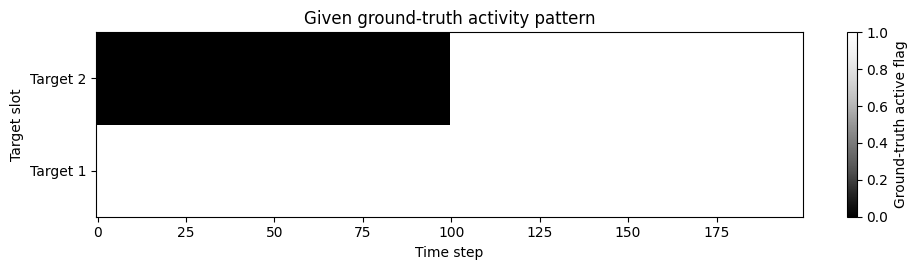

In [ ]:
plt.figure(figsize=(10, 2.8))
plt.imshow(
    true_active.T,
    aspect="auto",
    interpolation="nearest",
    cmap="Greys_r",
    origin="lower",
)
plt.yticks(np.arange(N_TARGETS), [f"Target {j + 1}" for j in range(N_TARGETS)])
plt.xlabel("Time step")
plt.ylabel("Target slot")
plt.title("Given ground-truth activity pattern")
plt.colorbar(label="Ground-truth active flag")
plt.tight_layout()
plt.show()

## Observation energy over time

This plot summarizes the generated complex observations over time.
The energy is computed as the squared norm over all frequency bins and microphones at each frame.

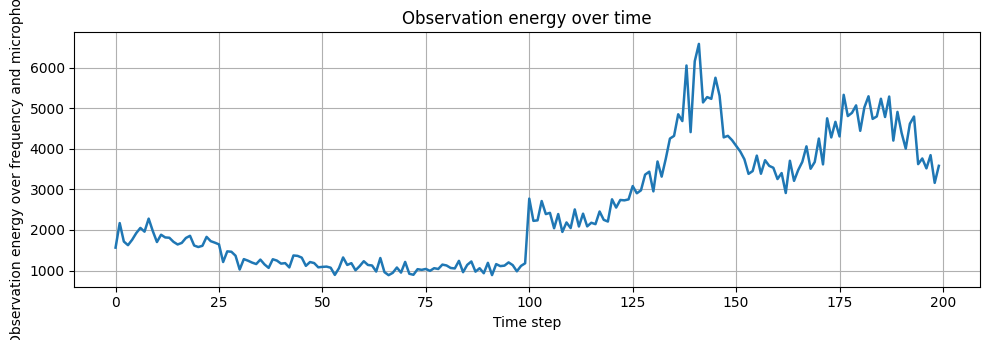

In [ ]:
obs_energy = np.sum(np.abs(case["obs_ts"]) ** 2, axis=(1, 2))

plt.figure(figsize=(10, 3.5))
plt.plot(np.arange(T_STEPS), obs_energy, lw=1.8)
plt.xlabel("Time step")
plt.ylabel("Observation energy over frequency and microphones")
plt.title("Observation energy over time")
plt.grid(True)
plt.tight_layout()
plt.show()


## Estimated position over time

This section plots particle clouds, MMSE estimates, and ground-truth positions over time. Separate x- and y-position plots are produced for the proposed and conventional methods. The gray particles show posterior spread, while the colored lines show target estimates.


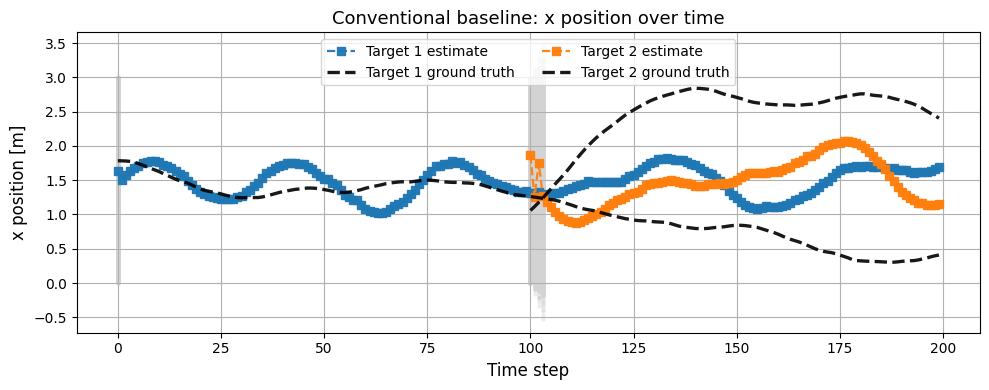

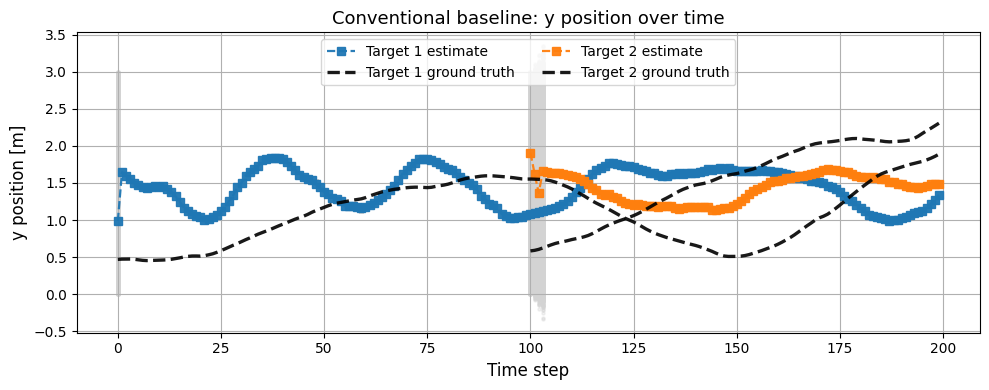

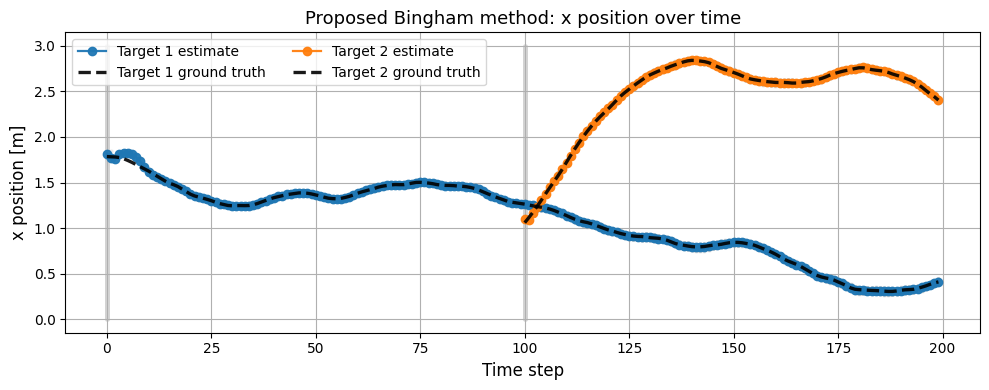

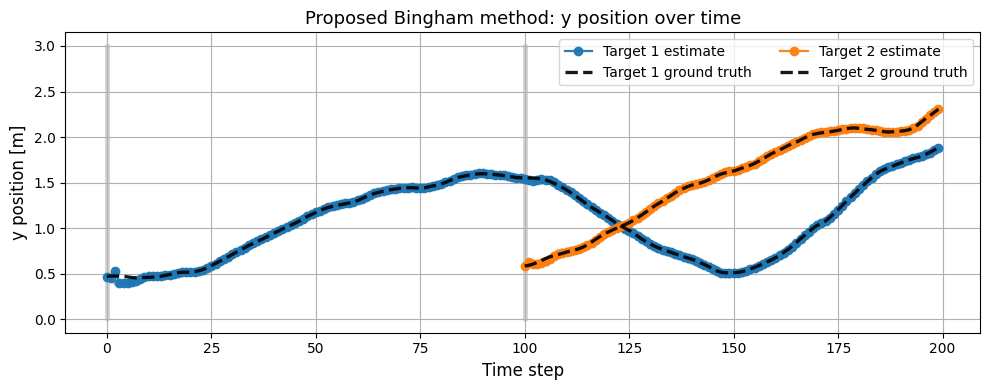

In [ ]:
cmap = plt.get_cmap("tab10")
colors = [cmap(j % 10) for j in range(N_TARGETS)]


def contiguous_segments(idx):
    if idx.size == 0:
        return []
    cuts = np.where(np.diff(idx) > 1)[0] + 1
    return np.split(idx, cuts)


def plot_position_time(
    pf,
    est_states,
    est_active,
    axis,
    title,
    marker="o-",
    legend_loc=None,
):
    history = np.array(pf.history)
    t = np.arange(T_STEPS)

    plt.figure(figsize=(10, 4))
    for j in range(N_TARGETS):
        idx_e = np.where(est_active[:, j] == 1)[0]
        for t_idx in idx_e:
            pts = history[t_idx, :, j, axis]
            plt.scatter(
                np.full_like(pts, t_idx),
                pts,
                color="lightgray",
                alpha=0.3,
                s=5,
                zorder=1,
            )

        for k, seg in enumerate(contiguous_segments(idx_e)):
            plt.plot(
                t[seg],
                est_states[seg, j, axis],
                marker,
                lw=1.6,
                alpha=0.95,
                color=colors[j],
                label=f"Target {j + 1} estimate" if k == 0 else None,
                zorder=2,
            )

        idx_t = np.where(true_active[:, j] == 1)[0]
        for k, seg in enumerate(contiguous_segments(idx_t)):
            plt.plot(
                t[seg],
                true_states[seg, j, axis],
                "--",
                lw=2.4,
                alpha=0.9,
                color="k",
                label=f"Target {j + 1} ground truth" if k == 0 else None,
                zorder=3,
            )

    axis_label = "x" if axis == 0 else "y"
    plt.xlabel("Time step", fontsize=12)
    plt.ylabel(f"{axis_label} position [m]", fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.title(title, fontsize=13)
    plt.grid(True)
    plt.legend(ncol=2, fontsize=10, loc=legend_loc)
    plt.tight_layout()
    plt.show()


plot_position_time(
    pf_conv,
    est_states_conv,
    est_active_conv,
    0,
    "Conventional baseline: x position over time",
    marker="s--",
    legend_loc="upper center",
)
plot_position_time(
    pf_conv,
    est_states_conv,
    est_active_conv,
    1,
    "Conventional baseline: y position over time",
    marker="s--",
    legend_loc="upper center",
)
plot_position_time(
    pf_prop,
    est_states_prop,
    est_active_prop,
    0,
    "Proposed Bingham method: x position over time",
)
plot_position_time(
    pf_prop,
    est_states_prop,
    est_active_prop,
    1,
    "Proposed Bingham method: y position over time",
)


## Position error over time

This plot compares the frame-wise position error of the proposed and conventional methods. Errors are computed only for target-time pairs active in the given ground-truth activity pattern. 


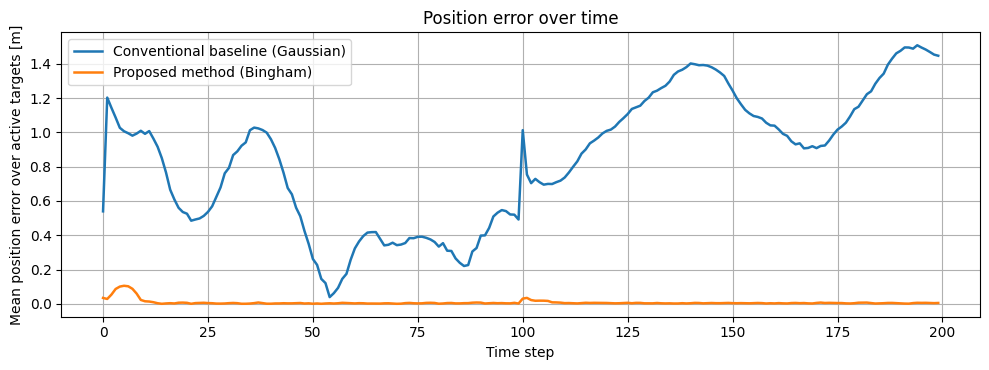

In [ ]:
def position_error_over_time(est_states, true_states, true_active):
    """Return mean position error per frame over active target slots."""
    per_target_error = np.linalg.norm(
        est_states[..., :2] - true_states[..., :2],
        axis=2,
    )
    active = true_active.astype(bool)
    frame_error = np.full(true_active.shape[0], np.nan)
    for t_idx in range(true_active.shape[0]):
        if np.any(active[t_idx]):
            frame_error[t_idx] = np.mean(per_target_error[t_idx, active[t_idx]])
    return frame_error


error_prop = position_error_over_time(est_states_prop, true_states, true_active)
error_conv = position_error_over_time(est_states_conv, true_states, true_active)

plt.figure(figsize=(10, 3.8))
plt.plot(error_conv, label="Conventional baseline (Gaussian)", lw=1.8)
plt.plot(error_prop, label="Proposed method (Bingham)", lw=1.8)
plt.xlabel("Time step")
plt.ylabel("Mean position error over active targets [m]")
plt.title("Position error over time")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## RMSE comparison

This bar plot summarizes the final position RMSE for the two likelihood choices. Both methods use the same generated trajectory, observations, particle count, and random seed.


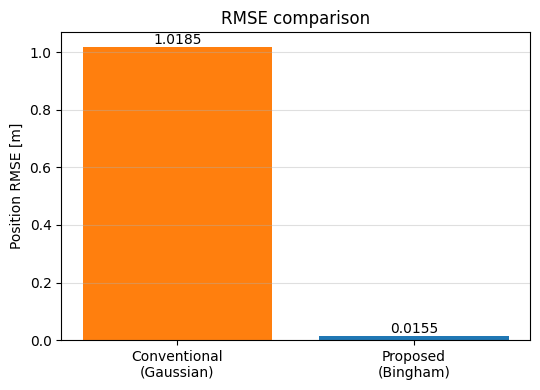

Conventional RMSE: 1.018516
Proposed RMSE: 0.015532


In [ ]:
method_names = ["Conventional\n(Gaussian)", "Proposed\n(Bingham)"]
rmse_values = [rmse_conv, rmse_prop]

plt.figure(figsize=(5.5, 4))
bars = plt.bar(method_names, rmse_values, color=["tab:orange", "tab:blue"])
plt.ylabel("Position RMSE [m]")
plt.title("RMSE comparison")
plt.grid(axis="y", alpha=0.4)
for bar, value in zip(bars, rmse_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom",
    )
plt.tight_layout()
plt.show()

print(f"Conventional RMSE: {rmse_conv:.6f}")
print(f"Proposed RMSE: {rmse_prop:.6f}")
